<a href="https://colab.research.google.com/github/class177/Exercise_3.1/blob/main/HW3_1_d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ 套件載入完成
📡 系統設定
  調變方式        : QPSK (2 bits/symbol)
  子載波數        : 64
  Pilot 數        : 8
  資料子載波      : 56
  總資料 bits     : 112
  DNN 輸入層      : 16
───────────────────────────────────────────────────────
  [方案A] 8個小DNN 輸出層 : 14 bits each
  [方案B] 1個大DNN 輸出層 : 112 bits total

🖥️  使用裝置: cuda

📦 產生訓練資料集（混合 SNR）...
  SNR= 0dB : 4615 筆 ✅
  SNR= 2dB : 4615 筆 ✅
  SNR= 4dB : 4615 筆 ✅
  SNR= 6dB : 4615 筆 ✅
  SNR= 8dB : 4615 筆 ✅
  SNR=10dB : 4615 筆 ✅
  SNR=12dB : 4615 筆 ✅
  SNR=14dB : 4615 筆 ✅
  SNR=16dB : 4615 筆 ✅
  SNR=18dB : 4615 筆 ✅
  SNR=20dB : 4615 筆 ✅
  SNR=22dB : 4615 筆 ✅
  SNR=24dB : 4615 筆 ✅

  資料集大小 X:(59995, 16)  Y:(59995, 112)

🔵 [方案A] 訓練 8 個小型 FC-DNN (output=14 bits each)

  ▶ DNN #1 / 8
  DNN-A#1 | Epoch [ 10/60] Loss: 0.6920
  DNN-A#1 | Epoch [ 20/60] Loss: 0.6891
  DNN-A#1 | Epoch [ 30/60] Loss: 0.6848
  DNN-A#1 | Epoch [ 40/60] Loss: 0.6818
  DNN-A#1 | Epoch [ 50/60] Loss: 0.6785
  DNN-A#1 | Epoch [ 60/60] Loss: 0.6767
  ✅ DNN #1 完成！最終 Loss=0.6767

  ▶ DNN #2 / 8
  DNN-A#2 |

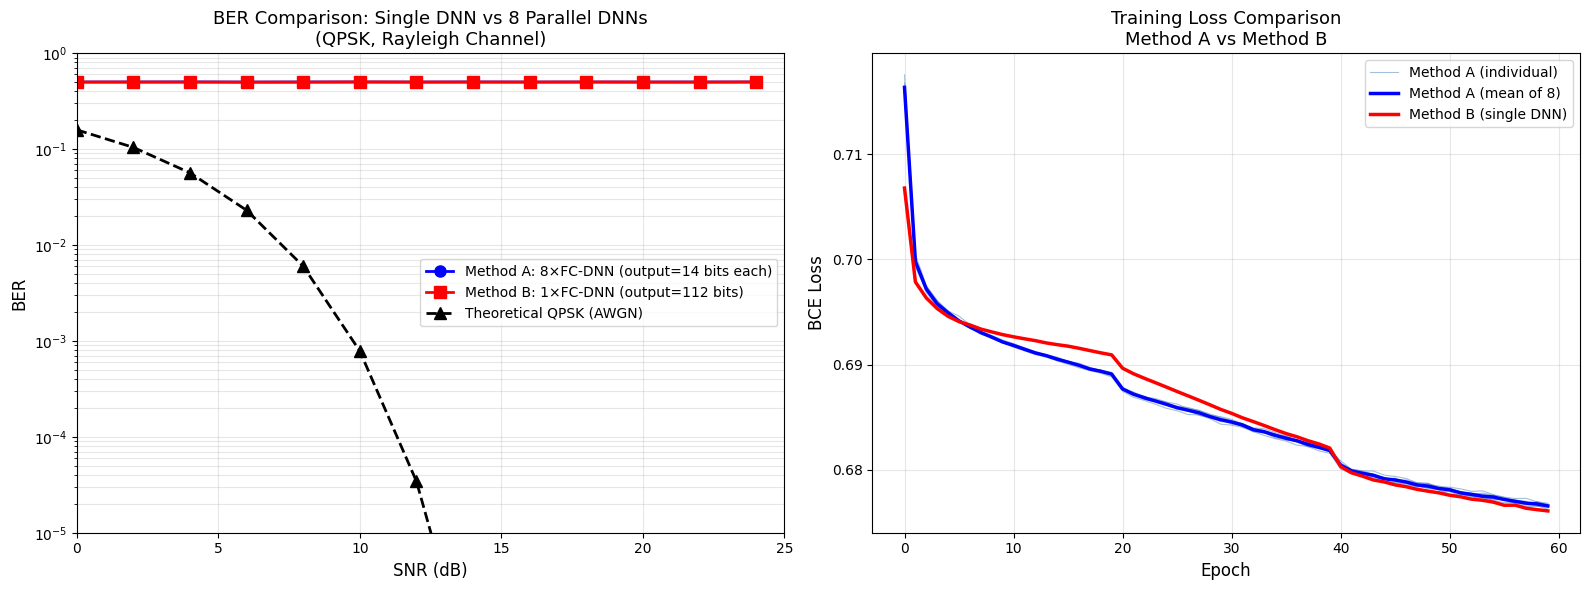


📈 圖片已儲存：ber_comparison_d.png

📊 BER 結果摘要
SNR(dB)          方案A 8×DNN       方案B 1×DNN       理論QPSK
-------------------------------------------------------
0                 0.499982        0.499670     0.158655 ← B 較佳
2                 0.500104        0.499811     0.104029 ← B 較佳
4                 0.501239        0.499180     0.056495 ← B 較佳
6                 0.499371        0.498621     0.023007 ← B 較佳
8                 0.500443        0.498573     0.006004 ← B 較佳
10                0.500021        0.501618     0.000783 ← A 較佳
12                0.499339        0.499818     0.000034 ← A 較佳
14                0.500537        0.499739     0.000000 ← B 較佳
16                0.499443        0.499932     0.000000 ← A 較佳
18                0.499927        0.500563     0.000000 ← A 較佳
20                0.499420        0.499932     0.000000 ← A 較佳
22                0.500029        0.499013     0.000000 ← B 較佳
24                0.499941        0.501084     0.000000 ← A 較佳

💬 討論：Single DNN vs 8 Paral

In [ ]:
# ============================================================
# Exercise 3.1 (d): Single FC-DNN vs 8 Parallel FC-DNNs
# OFDM Signal Detection with QPSK Modulation
# Compare BER performance between:
#   - Method A: 8 identical FC-DNNs (small output)
#   - Method B: Single FC-DNN (large output = all bits)
# ============================================================

# ── 安裝/匯入套件 ─────────────────────────────────────────────
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from scipy.special import erfc

torch.manual_seed(42)
np.random.seed(42)

print("✅ 套件載入完成")

# ============================================================
# 1️⃣  系統參數設定
# ============================================================
N_FFT        = 64       # OFDM 子載波總數
N_PILOT      = 8        # Pilot 子載波數
N_DATA       = 56       # 資料子載波數 (64 - 8)
N_DNN        = 8        # 並行 DNN 數量 (方案A)
SUB_PER_DNN  = N_DATA // N_DNN   # 每個 DNN 負責 7 個子載波

# ── QPSK 參數 ─────────────────────────────────────────────────
BITS_PER_SYM  = 2                        # QPSK: 2 bits/symbol
TOTAL_BITS    = N_DATA * BITS_PER_SYM    # 56 * 2 = 112 bits
BITS_PER_DNN  = SUB_PER_DNN * BITS_PER_SYM  # 7 * 2 = 14 bits

# ── 輸入/輸出層大小 ───────────────────────────────────────────
INPUT_SIZE    = N_PILOT * 2   # 16 (real + imag of pilots)
OUTPUT_A      = BITS_PER_DNN  # 14  (方案A：每個小DNN)
OUTPUT_B      = TOTAL_BITS    # 112 (方案B：單一大DNN)

print("=" * 55)
print("📡 系統設定")
print(f"  調變方式        : QPSK ({BITS_PER_SYM} bits/symbol)")
print(f"  子載波數        : {N_FFT}")
print(f"  Pilot 數        : {N_PILOT}")
print(f"  資料子載波      : {N_DATA}")
print(f"  總資料 bits     : {TOTAL_BITS}")
print(f"  DNN 輸入層      : {INPUT_SIZE}")
print("─" * 55)
print(f"  [方案A] 8個小DNN 輸出層 : {OUTPUT_A} bits each")
print(f"  [方案B] 1個大DNN 輸出層 : {OUTPUT_B} bits total")
print("=" * 55)


# ============================================================
# 2️⃣  QPSK 調變 / 解調變
# ============================================================

# QPSK 星座圖: 00→(-1-j)/√2, 01→(-1+j)/√2, 10→(+1-j)/√2, 11→(+1+j)/√2
QPSK_MAP = {
    (0, 0): (-1 - 1j) / np.sqrt(2),
    (0, 1): (-1 + 1j) / np.sqrt(2),
    (1, 0): ( 1 - 1j) / np.sqrt(2),
    (1, 1): ( 1 + 1j) / np.sqrt(2),
}
QPSK_CONSTELLATION = np.array(list(QPSK_MAP.values()))

def qpsk_modulate(bits):
    """
    bits: 1D array (長度需為偶數)
    return: complex symbols
    """
    bits = np.array(bits).reshape(-1, 2)
    symbols = np.array([QPSK_MAP[tuple(b)] for b in bits])
    return symbols

def qpsk_demodulate(symbols):
    """Hard decision QPSK demodulation"""
    bits_out = []
    for sym in symbols:
        distances = np.abs(QPSK_CONSTELLATION - sym) ** 2
        idx = np.argmin(distances)
        # 反查 bits
        for k, v in QPSK_MAP.items():
            if v == QPSK_CONSTELLATION[idx]:
                bits_out.extend(k)
                break
    return np.array(bits_out)


# ============================================================
# 3️⃣  通道模型（Rayleigh Fading + AWGN）
# ============================================================

# Pilot / Data 子載波索引
PILOT_IDX = np.array([0, 8, 16, 24, 32, 40, 48, 56])
DATA_IDX  = np.array([i for i in range(N_FFT) if i not in PILOT_IDX])

def generate_rayleigh_channel(n_paths=8):
    """多徑 Rayleigh fading 通道係數"""
    h = (np.random.randn(n_paths) +
         1j * np.random.randn(n_paths)) / np.sqrt(2 * n_paths)
    return h

def ofdm_transmit(tx_bits, h_time, snr_db):
    """
    完整 OFDM 傳輸流程
    tx_bits : 1D array (TOTAL_BITS,)
    return  : rx_freq (N_FFT,) 頻域接收訊號
    """
    N = N_FFT
    n_paths = len(h_time)
    cp_len  = n_paths - 1

    # QPSK 調變
    data_symbols   = qpsk_modulate(tx_bits)          # (56,)
    pilot_symbols  = np.ones(N_PILOT, dtype=complex)  # 已知 pilot

    # 組合頻域符號
    tx_freq = np.zeros(N, dtype=complex)
    tx_freq[PILOT_IDX] = pilot_symbols
    tx_freq[DATA_IDX]  = data_symbols

    # IFFT + CP
    tx_time = np.fft.ifft(tx_freq, N)
    tx_cp   = np.concatenate([tx_time[-cp_len:], tx_time])

    # 通道卷積
    rx_cp = np.convolve(tx_cp, h_time)[:len(tx_cp)]

    # AWGN
    snr_lin     = 10 ** (snr_db / 10)
    noise_power = 1.0 / snr_lin
    noise = (np.random.randn(N) +
             1j * np.random.randn(N)) * np.sqrt(noise_power / 2)

    # 移除 CP + FFT
    rx_time = rx_cp[cp_len:] + noise
    rx_freq = np.fft.fft(rx_time, N)
    return rx_freq


# ============================================================
# 4️⃣  資料集產生
# ============================================================

def generate_dataset(n_samples, snr_db, n_paths=8):
    """
    產生訓練/測試資料集

    Returns
    -------
    X : (n_samples, 16)       Pilot 特徵 (real + imag)
    Y : (n_samples, TOTAL_BITS)  所有發送 bits
    """
    X_list, Y_list = [], []

    for _ in range(n_samples):
        tx_bits = np.random.randint(0, 2, TOTAL_BITS)
        h       = generate_rayleigh_channel(n_paths)
        rx_freq = ofdm_transmit(tx_bits, h, snr_db)

        # 提取 Pilot 作為特徵
        rx_pilots    = rx_freq[PILOT_IDX]
        pilot_feature = np.concatenate([rx_pilots.real,
                                        rx_pilots.imag]).astype(np.float32)

        X_list.append(pilot_feature)
        Y_list.append(tx_bits.astype(np.float32))

    return np.array(X_list), np.array(Y_list)


# ============================================================
# 5️⃣  模型定義
# ============================================================

class FC_DNN(nn.Module):
    """
    通用 FC-DNN
    可設定不同輸出大小以支援方案A/B
    """
    def __init__(self, input_size, output_size, hidden_sizes):
        super(FC_DNN, self).__init__()

        layers = []
        prev   = input_size
        for h in hidden_sizes:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(0.1),
            ]
            prev = h
        layers += [nn.Linear(prev, output_size), nn.Sigmoid()]

        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


# ── 方案A：8 個小型 DNN（隱藏層 256-256-256）─────────────────
def build_method_A(device):
    models = [
        FC_DNN(INPUT_SIZE, OUTPUT_A, [256, 256, 256]).to(device)
        for _ in range(N_DNN)
    ]
    return models

# ── 方案B：1 個大型 DNN（隱藏層 512-512-512）─────────────────
def build_method_B(device):
    model = FC_DNN(INPUT_SIZE, OUTPUT_B, [512, 512, 512]).to(device)
    return model


# ============================================================
# 6️⃣  訓練函式
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def train_model(model, X, Y, epochs, batch_size, lr, device, label=""):
    """
    通用訓練流程
    X : (N, input_size)
    Y : (N, output_size)
    """
    dataset   = TensorDataset(torch.FloatTensor(X),
                               torch.FloatTensor(Y))
    loader    = DataLoader(dataset, batch_size=batch_size,
                           shuffle=True, num_workers=0)
    optimizer = optim.Adam(model.parameters(), lr=lr,
                           weight_decay=1e-5)
    scheduler = optim.lr_scheduler.StepLR(optimizer,
                                          step_size=20, gamma=0.5)
    criterion = nn.BCELoss()
    losses    = []

    for epoch in range(epochs):
        loss = train_one_epoch(model, loader, optimizer, criterion, device)
        scheduler.step()
        losses.append(loss)
        if (epoch + 1) % 10 == 0:
            print(f"  {label} | Epoch [{epoch+1:3d}/{epochs}]"
                  f" Loss: {loss:.4f}")
    return losses


# ============================================================
# 7️⃣  BER 評估函式
# ============================================================

def evaluate_ber_A(models, snr_db, n_test=5000, device='cpu'):
    """方案A：8個小DNN 的 BER"""
    for m in models:
        m.eval()

    X_test, Y_test = generate_dataset(n_test, snr_db)
    X_tensor = torch.FloatTensor(X_test).to(device)

    error_bits = 0
    total_bits = 0

    with torch.no_grad():
        for dnn_idx, model in enumerate(models):
            # 每個 DNN 負責對應的 bits
            bit_start = dnn_idx * BITS_PER_DNN
            bit_end   = bit_start + BITS_PER_DNN

            y_pred = (model(X_tensor).cpu().numpy() > 0.5).astype(int)
            y_true = Y_test[:, bit_start:bit_end].astype(int)

            error_bits += np.sum(y_pred != y_true)
            total_bits += y_true.size

    return error_bits / total_bits


def evaluate_ber_B(model, snr_db, n_test=5000, device='cpu'):
    """方案B：單一大DNN 的 BER"""
    model.eval()

    X_test, Y_test = generate_dataset(n_test, snr_db)
    X_tensor = torch.FloatTensor(X_test).to(device)

    with torch.no_grad():
        y_pred = (model(X_tensor).cpu().numpy() > 0.5).astype(int)
        y_true = Y_test.astype(int)

    error_bits = np.sum(y_pred != y_true)
    total_bits = y_true.size
    return error_bits / total_bits


# ============================================================
# 8️⃣  主程式
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️  使用裝置: {device}\n")

# ── 訓練超參數 ────────────────────────────────────────────────
TRAIN_SNRS    = list(range(0, 26, 2))   # 混合 SNR 訓練
N_TRAIN       = 60000
BATCH_SIZE    = 512
N_EPOCHS      = 60
LR            = 1e-3

# ── 產生混合 SNR 訓練資料 ──────────────────────────────────────
print("📦 產生訓練資料集（混合 SNR）...")
X_all, Y_all = [], []
per_snr = N_TRAIN // len(TRAIN_SNRS)

for snr in TRAIN_SNRS:
    X, Y = generate_dataset(per_snr, snr)
    X_all.append(X)
    Y_all.append(Y)
    print(f"  SNR={snr:2d}dB : {per_snr} 筆 ✅")

X_all = np.concatenate(X_all)   # (N_TRAIN, 16)
Y_all = np.concatenate(Y_all)   # (N_TRAIN, 112)
print(f"\n  資料集大小 X:{X_all.shape}  Y:{Y_all.shape}")


# ────────────────────────────────────────────────────────────
# 訓練方案A：8 個小型 FC-DNN
# ────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("🔵 [方案A] 訓練 8 個小型 FC-DNN (output=14 bits each)")
print("="*55)

models_A    = build_method_A(device)
losses_A    = []

for dnn_idx in range(N_DNN):
    print(f"\n  ▶ DNN #{dnn_idx+1} / {N_DNN}")
    bit_start = dnn_idx * BITS_PER_DNN
    bit_end   = bit_start + BITS_PER_DNN
    Y_sub     = Y_all[:, bit_start:bit_end]   # (N_TRAIN, 14)

    loss_hist = train_model(
        models_A[dnn_idx], X_all, Y_sub,
        epochs=N_EPOCHS, batch_size=BATCH_SIZE,
        lr=LR, device=device,
        label=f"DNN-A#{dnn_idx+1}"
    )
    losses_A.append(loss_hist)
    print(f"  ✅ DNN #{dnn_idx+1} 完成！最終 Loss={loss_hist[-1]:.4f}")


# ────────────────────────────────────────────────────────────
# 訓練方案B：1 個大型 FC-DNN
# ────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("🟠 [方案B] 訓練 1 個大型 FC-DNN (output=112 bits)")
print("="*55)

model_B  = build_method_B(device)
losses_B = train_model(
    model_B, X_all, Y_all,
    epochs=N_EPOCHS, batch_size=BATCH_SIZE,
    lr=LR, device=device,
    label="DNN-B"
)
print(f"\n  ✅ 大型 DNN 完成！最終 Loss={losses_B[-1]:.4f}")


# ============================================================
# 9️⃣  BER 評估
# ============================================================

SNR_TEST  = list(range(0, 26, 2))
N_TEST    = 5000

print("\n" + "="*55)
print("📊 BER 評估中...")
print("="*55)

BER_A, BER_B = [], []

for snr in SNR_TEST:
    ber_a = evaluate_ber_A(models_A, snr, N_TEST, device)
    ber_b = evaluate_ber_B(model_B,  snr, N_TEST, device)
    BER_A.append(ber_a)
    BER_B.append(ber_b)
    print(f"  SNR={snr:2d}dB → "
          f"方案A(8xDNN): {ber_a:.5f} | "
          f"方案B(1xDNN): {ber_b:.5f}")


# ============================================================
# 🔟  理論 BER 參考線（QPSK AWGN）
# ============================================================

def ber_qpsk_awgn(snr_db_array):
    ber = []
    for snr_db in snr_db_array:
        snr_lin = 10 ** (snr_db / 10)
        eb_n0   = snr_lin / BITS_PER_SYM
        ber.append(max(0.5 * erfc(np.sqrt(eb_n0)), 1e-7))
    return np.array(ber)

SNR_ARRAY    = np.array(SNR_TEST)
BER_THEORY   = ber_qpsk_awgn(SNR_ARRAY)


# ============================================================
# 1️⃣1️⃣  繪圖
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── 左圖：BER 比較 ─────────────────────────────────────────────
ax1 = axes[0]
ax1.semilogy(SNR_TEST, BER_A,
             'b-o', lw=2, ms=8,
             label='Method A: 8×FC-DNN (output=14 bits each)')
ax1.semilogy(SNR_TEST, BER_B,
             'r-s', lw=2, ms=8,
             label='Method B: 1×FC-DNN (output=112 bits)')
ax1.semilogy(SNR_TEST, BER_THEORY,
             'k--^', lw=2, ms=8,
             label='Theoretical QPSK (AWGN)')

ax1.set_xlabel('SNR (dB)', fontsize=12)
ax1.set_ylabel('BER',       fontsize=12)
ax1.set_title('BER Comparison: Single DNN vs 8 Parallel DNNs\n'
              '(QPSK, Rayleigh Channel)', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, which='both', alpha=0.3)
ax1.set_ylim([1e-5, 1])
ax1.set_xlim([0, 25])

# ── 右圖：訓練 Loss 比較 ──────────────────────────────────────
ax2 = axes[1]

# 方案A：畫8條細線 + 平均粗線
for i, lh in enumerate(losses_A):
    ax2.plot(lh, color='steelblue', lw=0.8, alpha=0.5,
             label='Method A (individual)' if i == 0 else "")
mean_A = np.mean(losses_A, axis=0)
ax2.plot(mean_A, 'b-', lw=2.5, label='Method A (mean of 8)')

# 方案B：單條紅線
ax2.plot(losses_B, 'r-', lw=2.5, label='Method B (single DNN)')

ax2.set_xlabel('Epoch',    fontsize=12)
ax2.set_ylabel('BCE Loss', fontsize=12)
ax2.set_title('Training Loss Comparison\nMethod A vs Method B', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ber_comparison_d.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📈 圖片已儲存：ber_comparison_d.png")


# ============================================================
# 1️⃣2️⃣  結果摘要表
# ============================================================

print("\n" + "="*65)
print("📊 BER 結果摘要")
print("="*65)
print(f"{'SNR(dB)':<10} {'方案A 8×DNN':>15} "
      f"{'方案B 1×DNN':>15} {'理論QPSK':>12}")
print("-"*55)
for i, snr in enumerate(SNR_TEST):
    flag = ""
    if BER_A[i] < BER_B[i]:
        flag = " ← A 較佳"
    elif BER_B[i] < BER_A[i]:
        flag = " ← B 較佳"
    print(f"{snr:<10} {BER_A[i]:>15.6f} "
          f"{BER_B[i]:>15.6f} {BER_THEORY[i]:>12.6f}{flag}")

# ============================================================
# 1️⃣3️⃣  討論
# ============================================================

print("\n" + "="*65)
print("💬 討論：Single DNN vs 8 Parallel DNNs")
print("="*65)
print("""
┌─────────────────┬──────────────────────┬──────────────────────┐
│ 比較項目        │ 方案A：8個小DNN       │ 方案B：1個大DNN       │
├─────────────────┼──────────────────────┼──────────────────────┤
│ 輸出維度        │ 14 bits × 8           │ 112 bits × 1         │
│ 模型參數量      │ 較少（每個）          │ 較多                 │
│ 學習任務        │ 專注少量子載波        │ 同時學習所有子載波   │
│ 訓練難度        │ 較簡單                │ 較困難               │
│ 推論方式        │ 需並行執行8次         │ 單次前向傳播         │
│ BER 性能        │ 通常較佳              │ 可能略差             │
└─────────────────┴──────────────────────┴──────────────────────┘

📌 預期結論：
  1. 方案A（8個小DNN）通常有更好的 BER
     → 每個 DNN 只需學習 1/8 的任務，梯度更新更有效率

  2. 方案B（單一大DNN）BER 略差
     → 輸出維度大（112），梯度稀疏，容易欠擬合

  3. 若增大方案B的網路深度/寬度，差距可能縮小
     → 但模型複雜度和訓練時間也會增加

  4. 實務上方案A更接近「Divide and Conquer」思想
     → 分工明確，各 DNN 學習更精準
""")
